# Riemann Sums: Area from Rectangles

**This notebook teaches integration from scratch, it assumes only that you can compute the area of a rectangle.**

Calculus has two halves. The first, derivatives, was about **rates of change**, how fast something is
moving. The second is about **accumulation**, how much has piled up. If a derivative takes a total
and finds a rate, an integral takes a rate and finds the total.

Geometrically the question is: **what is the area under a curve?** For a rectangle that is trivial. For
a curved shape there is no formula, so we do what §3.1 taught: replace the impossible problem with a
solvable one. Cover the region with rectangles, add their areas, and use thinner rectangles until the
answer stops changing.

## Learning objectives

- Approximate the area under a curve with a **Riemann sum**.
- Compare the **left**, **right**, **midpoint**, and **trapezoid** rules.
- Watch the approximation **converge** as the number of rectangles grows.

## Background

To find the area under $f(x)$ between $a$ and $b$, chop the interval into $n$ pieces each of width

$$\Delta x = \frac{b - a}{n}$$

and approximate each strip by a rectangle. The only question is how tall to make each one:

- **left rule**: use the function's value at the strip's left edge, $f(x_i)$;
- **right rule**: use the right edge, $f(x_{i+1})$;
- **midpoint rule**: use the middle, $f\!\left(\frac{x_i + x_{i+1}}{2}\right)$;
- **trapezoid rule**: average the two edges, $\frac{f(x_i) + f(x_{i+1})}{2}$, which slants the top.

Adding them gives a **Riemann sum**, e.g. $\sum_i f(x_i)\,\Delta x$. As $n \to \infty$ every rule
converges to the same number, and *that* limit is the **definite integral**:

$$\int_a^b f(x)\,dx = \lim_{n\to\infty} \sum_{i} f(x_i)\,\Delta x$$

The $\int$ sign is a stretched "S" for *sum*, and $dx$ is what $\Delta x$ becomes in the limit, the
notation is a picture of the construction.

## This notebook covers

1. One rectangle, then a few.
2. The four rules compared.
3. Convergence as $n$ grows.
4. Which rule is best.

**Prerequisites:** `U3-1_Approximation-1_ModelsAndError`

**Dataset:** none, a known function, so the exact area is available for comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Covering a curve with rectangles

Take $f(x) = x^2 + 1$ on $[0, 3]$. Its exact area is $\int_0^3 (x^2+1)\,dx = 12$, we will confirm that
later, but for now it is simply the target to hit.

Start with a deliberately crude approximation: 4 rectangles, each using the function's value at its
**left** edge. The rectangles clearly miss, they undershoot on a rising curve, because the left edge
is the lowest point of each strip.

In [2]:
def f(x):
    return x**2 + 1

a, b = 0.0, 3.0
exact = 12.0          # the true area, for comparison

def riemann(f, a, b, n, rule="left"):
    edges = np.linspace(a, b, n + 1)
    dx = (b - a) / n
    if rule == "left":
        heights = f(edges[:-1])
    elif rule == "right":
        heights = f(edges[1:])
    elif rule == "midpoint":
        heights = f((edges[:-1] + edges[1:]) / 2)
    elif rule == "trapezoid":
        heights = (f(edges[:-1]) + f(edges[1:])) / 2
    return np.sum(heights) * dx

for n in [4, 10, 50, 500]:
    approx = riemann(f, a, b, n, "left")
    print(f"n = {n:4d} rectangles -> area ~ {approx:9.5f}   (exact {exact}, off by {abs(approx-exact):.5f})")

n =    4 rectangles -> area ~   8.90625   (exact 12.0, off by 3.09375)
n =   10 rectangles -> area ~  10.69500   (exact 12.0, off by 1.30500)
n =   50 rectangles -> area ~  11.73180   (exact 12.0, off by 0.26820)
n =  500 rectangles -> area ~  11.97302   (exact 12.0, off by 0.02698)


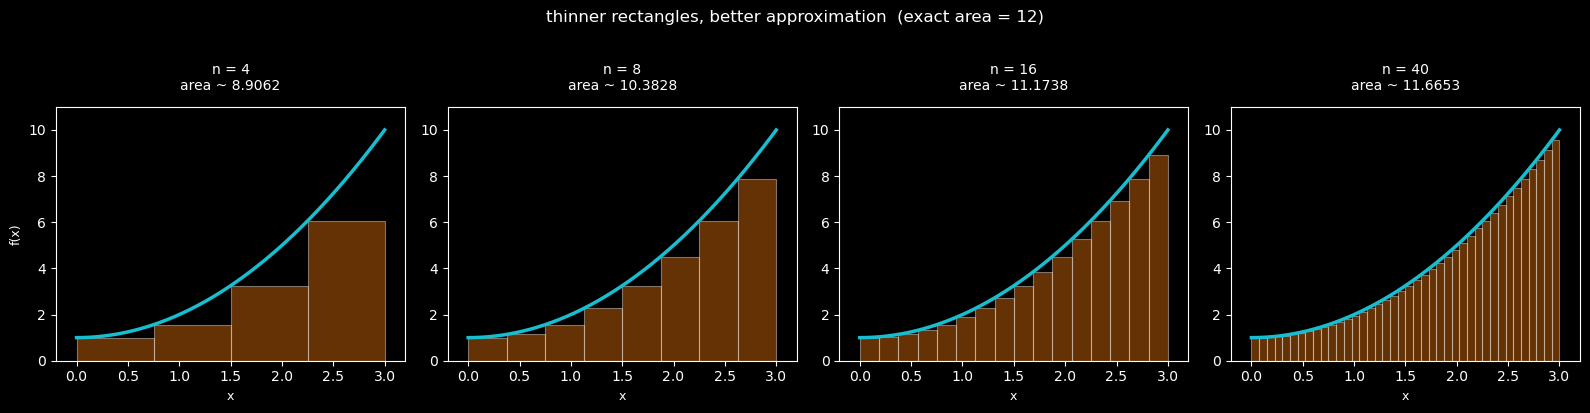

In [3]:
def draw_rectangles(ax, f, a, b, n, rule, color):
    edges = np.linspace(a, b, n + 1)
    dx = (b - a) / n
    xs = np.linspace(a, b, 400)
    ax.plot(xs, f(xs), color="tab:cyan", lw=2.5, zorder=5)
    for lo, hi in zip(edges[:-1], edges[1:]):
        if rule == "left":       h = f(lo)
        elif rule == "right":    h = f(hi)
        elif rule == "midpoint": h = f((lo + hi) / 2)
        else:                    h = None
        if rule == "trapezoid":
            ax.fill([lo, hi, hi, lo], [0, 0, f(hi), f(lo)],
                    color=color, alpha=0.4, edgecolor="white", lw=0.8)
        else:
            ax.add_patch(plt.Rectangle((lo, 0), dx, h, facecolor=color,
                                       alpha=0.4, edgecolor="white", lw=0.8))
    ax.set_xlim(a - 0.2, b + 0.2)
    ax.set_ylim(0, f(b) * 1.1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n in zip(axes, [4, 8, 16, 40]):
    draw_rectangles(ax, f, a, b, n, "left", "tab:orange")
    approx = riemann(f, a, b, n, "left")
    ax.set_xlabel("x", fontsize=9)
    ax.set_title(f"n = {n}\narea ~ {approx:.4f}", pad=12, fontsize=10)
axes[0].set_ylabel("f(x)", fontsize=9)
plt.suptitle("thinner rectangles, better approximation  (exact area = 12)", y=1.02)
plt.tight_layout()
plt.show()

## 2. The four rules

Same curve, same number of rectangles, four different choices of height. Watch how each one errs:

- **left** undershoots on a rising curve (each rectangle is set by the strip's lowest point);
- **right** overshoots for the same reason, from the other side;
- **midpoint** and **trapezoid** split the difference and do far better.

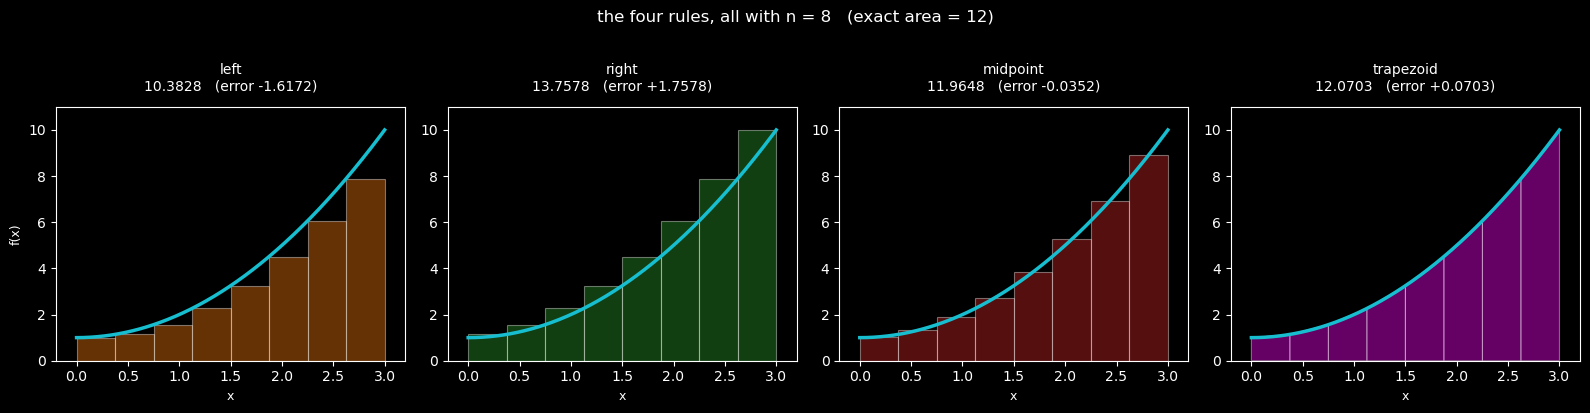

In [4]:
n = 8
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
rules = [("left", "tab:orange"), ("right", "tab:green"),
         ("midpoint", "tab:red"), ("trapezoid", "magenta")]
for ax, (rule, color) in zip(axes, rules):
    draw_rectangles(ax, f, a, b, n, rule, color)
    approx = riemann(f, a, b, n, rule)
    ax.set_xlabel("x", fontsize=9)
    ax.set_title(f"{rule}\n{approx:.4f}   (error {approx-exact:+.4f})", pad=12, fontsize=10)
axes[0].set_ylabel("f(x)", fontsize=9)
plt.suptitle(f"the four rules, all with n = {n}   (exact area = 12)", y=1.02)
plt.tight_layout()
plt.show()

In [5]:
print(f"with n = {n} rectangles:\n")
print(f"{'rule':<12} {'estimate':>12} {'error':>12}")
print("-" * 38)
for rule, _ in rules:
    est = riemann(f, a, b, n, rule)
    print(f"{rule:<12} {est:12.6f} {est - exact:+12.6f}")
print("-" * 38)
print(f"{'exact':<12} {exact:12.6f}")
print("\nleft and right miss by the same amount in opposite directions --")
print("which is exactly why averaging them (the trapezoid rule) does so much better.")

with n = 8 rectangles:

rule             estimate        error
--------------------------------------
left            10.382812    -1.617188
right           13.757812    +1.757812
midpoint        11.964844    -0.035156
trapezoid       12.070312    +0.070312
--------------------------------------
exact           12.000000

left and right miss by the same amount in opposite directions --
which is exactly why averaging them (the trapezoid rule) does so much better.


## 3. Convergence

The definition says the answer is the **limit** as $n \to \infty$. Watch the error shrink as the
rectangles get thinner, the same limiting idea as §3.2, now applied to areas rather than slopes.

Plotted on log-log axes, the slope of each line says how fast that rule converges (the same trick
used for finite differences in §3.4).

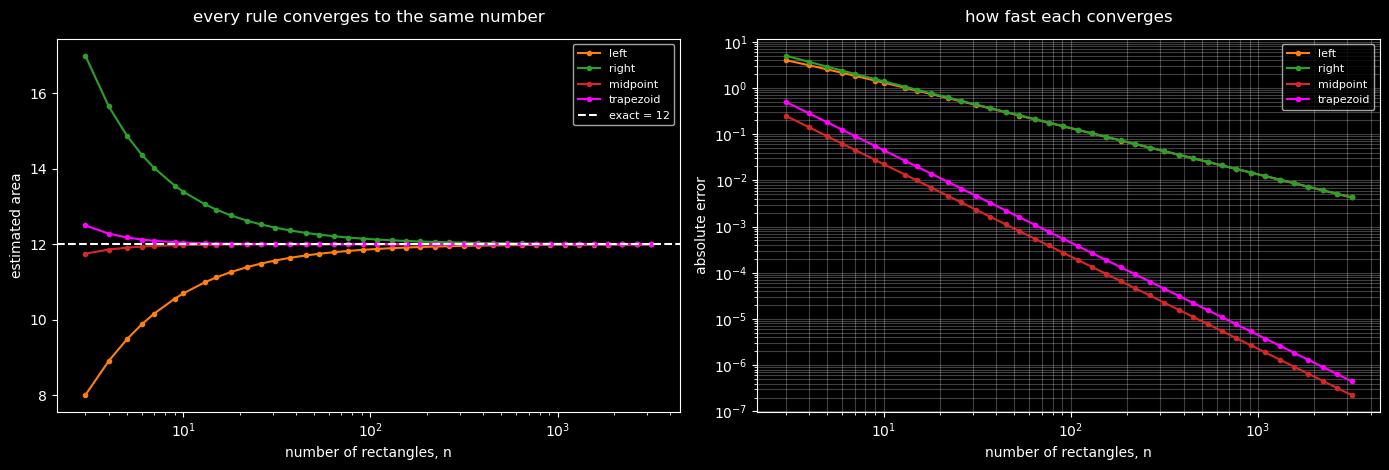

In [6]:
ns = np.unique(np.logspace(0.5, 3.5, 40).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for rule, color in rules:
    ests = np.array([riemann(f, a, b, n, rule) for n in ns])
    axes[0].plot(ns, ests, "o-", color=color, markersize=3, label=rule)
    axes[1].loglog(ns, np.abs(ests - exact), "o-", color=color, markersize=3, label=rule)

axes[0].axhline(exact, color="white", ls="--", lw=1.5, label="exact = 12")
axes[0].set_xscale("log")
axes[0].set_xlabel("number of rectangles, n")
axes[0].set_ylabel("estimated area")
axes[0].legend(fontsize=8)
axes[0].set_title("every rule converges to the same number", pad=12)

axes[1].set_xlabel("number of rectangles, n")
axes[1].set_ylabel("absolute error")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25, which="both")
axes[1].set_title("how fast each converges", pad=12)

plt.tight_layout()
plt.show()

In [7]:
# measure the convergence rates from the log-log slopes
print(f"{'rule':<12} {'measured slope':>16}   meaning")
print("-" * 62)
for rule, _ in rules:
    ests = np.array([riemann(f, a, b, n, rule) for n in ns])
    err = np.abs(ests - exact)
    m = err > 1e-12
    slope = np.polyfit(np.log10(ns[m]), np.log10(err[m]), 1)[0]
    meaning = "double n, halve the error" if slope > -1.5 else "double n, quarter the error"
    print(f"{rule:<12} {slope:16.2f}   {meaning}")
print("-" * 62)
print("\nleft and right converge like 1/n; midpoint and trapezoid like 1/n^2 --")
print("the same kind of accuracy ordering seen for finite differences in section 3.4.")

rule           measured slope   meaning
--------------------------------------------------------------
left                    -0.99   double n, halve the error
right                   -1.01   double n, halve the error
midpoint                -2.00   double n, quarter the error
trapezoid               -2.00   double n, quarter the error
--------------------------------------------------------------

left and right converge like 1/n; midpoint and trapezoid like 1/n^2 --
the same kind of accuracy ordering seen for finite differences in section 3.4.


## 4. Which rule, and why it matters

Midpoint and trapezoid are dramatically better for the same amount of work, so in practice nobody uses
the left rule except to explain the idea. NumPy ships the trapezoid rule as `np.trapz`.

The general lesson is the same one from §3.4: **how you arrange the arithmetic matters as much as how
finely you chop.** Going from left to trapezoid buys more accuracy than a tenfold increase in $n$.

In [8]:
# note: np.trapz works on NumPy 1.x. It was renamed np.trapezoid in NumPy 2.0,
# so on a newer NumPy swap the name (the arguments are unchanged).
n_small = 20
xs = np.linspace(a, b, n_small + 1)
print(f"trapezoid by hand,  n = {n_small}: {riemann(f, a, b, n_small, 'trapezoid'):.8f}")
print(f"np.trapz,       n = {n_small}: {np.trapz(f(xs), xs):.8f}")
print(f"exact                          : {exact:.8f}")
print()
print(f"left rule with n = 20    : error {abs(riemann(f,a,b,20,'left') - exact):.5f}")
print(f"left rule with n = 200   : error {abs(riemann(f,a,b,200,'left') - exact):.5f}")
print(f"trapezoid with n = 20    : error {abs(riemann(f,a,b,20,'trapezoid') - exact):.5f}")
print("\nthe trapezoid rule with 20 rectangles beats the left rule with 200.")

trapezoid by hand,  n = 20: 12.01125000
np.trapz,       n = 20: 12.01125000
exact                          : 12.00000000

left rule with n = 20    : error 0.66375
left rule with n = 200   : error 0.06739
trapezoid with n = 20    : error 0.01125

the trapezoid rule with 20 rectangles beats the left rule with 200.


## 5. Summary

- The area under a curve is approximated by covering it with **rectangles** and adding their areas, a
  **Riemann sum**.
- The rules differ only in how each rectangle's height is chosen: **left**, **right**, **midpoint**,
  **trapezoid**.
- All converge to the same limit as $n \to \infty$, and that limit **is** the definite integral
  $\int_a^b f(x)\,dx$.
- **Midpoint and trapezoid converge like $1/n^2$**; left and right only like $1/n$. Choosing the right
  rule beats brute force.
- The notation is a picture of the construction: $\int$ is a stretched S for *sum*, and $dx$ is the
  limit of $\Delta x$.

Next: the astonishing fact that integration and differentiation **undo each other**
(`U3-8_Integrals-2_FundamentalTheorem`).